 Semantic Similarity Search

In [1]:
pip install tensorflow_hub

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import pandas as pd
import os

In [3]:
import sys
print(sys.version)
tf.version

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


<module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.12/dist-packages/tensorflow/_api/v2/version/__init__.py'>

In [4]:
module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model = hub.load(module_url) #download and load the model
print("Done!")

Done!


In [8]:
import os

# Load data
outpath = r"/content"
infile = os.path.join(outpath, "tmdb_5000_movies.csv")

# only read the first nrows
df = pd.read_csv(infile, nrows=50000)
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [9]:
df = df[['original_title']]
print(len(df))
df.head(6)

4803


,original_title
0,Avatar
1,Pirates of the Caribbean: At World's End
2,Spectre
3,The Dark Knight Rises
4,John Carter
5,Spider-Man 3


In [10]:
df['original_title'] = df['original_title'].str.lower()
df

,original_title
0,avatar
1,pirates of the caribbean: at world's end
2,spectre
3,the dark knight rises
4,john carter
...,...
4798,el mariachi
4799,newlyweds
4800,"signed, sealed, delivered"
4801,shanghai calling


In [11]:
# creating my empty list
doc = []

# Iterate over each row
for index, rows in df.iterrows():
    # Create list for the current row
    mylist =[rows.original_title]
    doc.append(mylist[0])

# Print the list doc
print(doc)

['avatar', "pirates of the caribbean: at world's end", 'spectre', 'the dark knight rises', 'john carter', 'spider-man 3', 'tangled', 'avengers: age of ultron', 'harry potter and the half-blood prince', 'batman v superman: dawn of justice', 'superman returns', 'quantum of solace', "pirates of the caribbean: dead man's chest", 'the lone ranger', 'man of steel', 'the chronicles of narnia: prince caspian', 'the avengers', 'pirates of the caribbean: on stranger tides', 'men in black 3', 'the hobbit: the battle of the five armies', 'the amazing spider-man', 'robin hood', 'the hobbit: the desolation of smaug', 'the golden compass', 'king kong', 'titanic', 'captain america: civil war', 'battleship', 'jurassic world', 'skyfall', 'spider-man 2', 'iron man 3', 'alice in wonderland', 'x-men: the last stand', 'monsters university', 'transformers: revenge of the fallen', 'transformers: age of extinction', 'oz: the great and powerful', 'the amazing spider-man 2', 'tron: legacy', 'cars 2', 'green lant

In [12]:
# How big is my data
print("Total number of text samples: ", len(doc))

Total number of text samples:  4803


In [13]:
# Vectorizing my data
bank_vec = model(doc)
print(bank_vec.shape)
print(bank_vec)

(4803, 512)
tf.Tensor(
[[-0.03512489 -0.04652002 -0.02655167 ... -0.0632797   0.07680548
  -0.06827117]
 [ 0.03366854 -0.03004143 -0.00926567 ... -0.06517767  0.08283427
  -0.02942577]
 [ 0.03810422 -0.07019217 -0.00290216 ... -0.03161626  0.07772547
   0.00989668]
 ...
 [-0.06502105 -0.00807046 -0.00714217 ... -0.02233556 -0.00615469
  -0.06248303]
 [ 0.04672126 -0.02552713  0.02765533 ... -0.02401352 -0.00806609
  -0.0584705 ]
 [-0.06564458 -0.05178279  0.03571627 ... -0.04576576  0.07359578
  -0.02721112]], shape=(4803, 512), dtype=float32)


In [14]:
# Vectoryzing my query
mystr = 'Heat'
#mystr = (mystr).upper()
print(mystr)
query = [mystr]
query_vec = model(query) #encodes the string in the list

Heat


In [15]:
# inner product calculation, recordando linear algebra
correlation = np.transpose(np.inner(query_vec,bank_vec))

In [16]:
result = str(doc[np.argmax(correlation, axis=0)[0]]).strip().format()
print(result)

the heat


In [17]:
print("Closest match found to '",query[0],"' is '",
      doc[np.argmax(correlation, axis=0)[0]],"'", np.argmax(correlation, axis=0),
      max(correlation))

Closest match found to ' Heat ' is ' the heat ' [1124] [0.82221544]


In [18]:
top_indices = np.argsort(correlation, axis=0)[-5:][::-1].squeeze()

# Print the top five matches
print(f"Top five closest matches and values to {query[0]} are:")
for idx in top_indices:
    print(doc[idx], correlation[idx])

# If you want to access the top five matches individually:
top_matches = [(doc[idx], correlation[idx]) for idx in top_indices]

Top five closest matches and values to Heat are:
the heat [0.82221544]
water [0.49686664]
burnt [0.48929363]
warm bodies [0.47296923]
hot pursuit [0.4674048]


# Exercise

- Do the same, same 5 movie titles, with the first 50.000 records, do the resulting five closest matches change?
- Do the same but this time change the movie title to "Dogs and Cats", report the 5 closest matches
- Try with longer titles and compare the results with shorter titles
- Do the same but this time use the "overview" field to try to come up with movies with similar context.
- Search for your own dataset from the internet and repeat the exercise
- Which applications do you think this approach support?
- Which other embedders similar to google/universal-sentence-encoder/4 can you find in the Internet? ## HuggingFace
  

# Exercise

- Do the same, same 5 movie titles, with the first 50.000 records, do the resulting five closest matches change?
- Do the same but this time change the movie title to "Dogs and Cats", report the 5 closest matches
- Try with longer titles and compare the results with shorter titles
- Do the same but this time use the "overview" field to try to come up with movies with similar context.
- Search for your own dataset from the internet and repeat the exercise
- Which applications do you think this approach support?
- Which other embedders similar to google/universal-sentence-encoder/4 can you find in the Internet? ## HuggingFace
  

Resultado inicial:


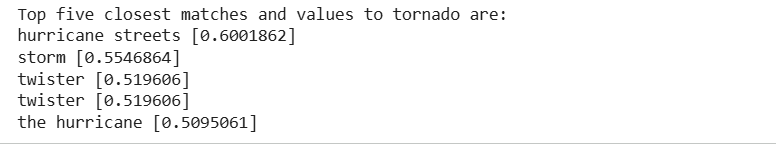

1. Cambiando a 50.000 records el top five es el siguiente:

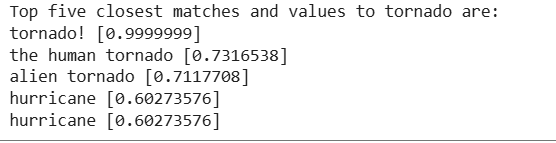

2. Usar "Dogs and Cats" y reportar el top 5.

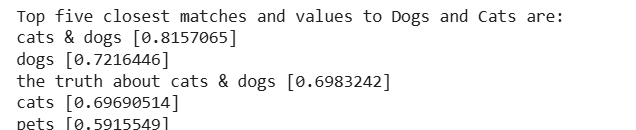

3. Try with longer titles and compare the results with shorter titles.

Primero probamos con el nombre "The Lord of the Rings: The Fellowship of the Ring" y luego con el título "Heat"

Para el título largo tenemos los siguientes resultados:

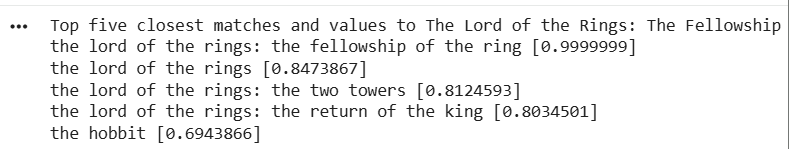

Luego para el título corto tenemos:

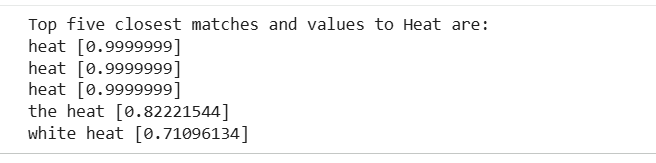

Evidentemente la similitud mejora cuando el título es corto.

4. Do the same but this time use the "overview" field to try to come up with movies with similar context.

Resultado: 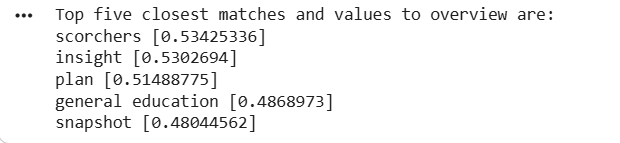

En este caso el modelo buscó títulos que tuvieran una relación conceptual o temática con la idea de un resumen o una descripción general, no necesariamente tienen el mismo nombre pero dichas palabras pueden ser usadas en el mismo contexto o están relacionadas.

5. Search for your own dataset from the internet and repeat the exercise

Se agregó el dataset tmbd_5000_movies.csv y el resultado, buscando "Heat" es el siguiente:


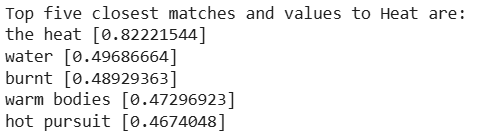

Comparandolo con el dataset anterior:

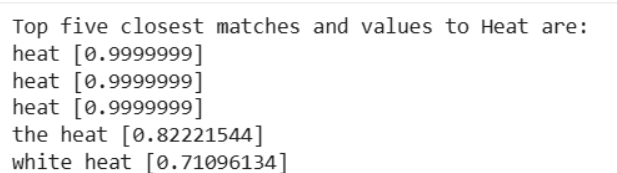

La similitud es mucho mejor en el primer dataset.


6. ¿Qué aplicaciones crees que admite este enfoque?

La aplicación más apropiada sería los buscadores de streaming, videos, inteligencia artificial relacionada con resomendaciones o consultas sobre películas.

7. ¿Qué otros embedders similares a google/universal-sentence-encoder/4 se pueden encontrar en Internet? ## HuggingFace

- Modelos de la familia BERT (Bidirectional Encoder Representations from Transformers)

- Modelos de la familia RoBERTa (A Robustly Optimized BERT Pretraining Approach

- Modelos de la familia XLM-RoBERTa

- Modelos de la familia ELECTRA